# Analyse Exploratoire du Dataset Fraud Detection

Ce notebook présente une EDA détaillée des fichiers `data/fraudTrain.csv` et `data/fraudTest.csv`.
L'objectif est de comprendre la structure des données, les variables disponibles, la qualité des données et les premiers patterns de fraude.

## 1. Chargement des librairies et configuration

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.style.use('seaborn-v0_8')
sns.set_context('talk')

## 2. Chargement des datasets et vérification des formes

In [20]:
train_path = 'data/fraudTrain.csv'
test_path = 'data/fraudTest.csv'

df_train = pd.read_csv(train_path, index_col=0, parse_dates=['trans_date_trans_time'], low_memory=False)
df_test = pd.read_csv(test_path, index_col=0, parse_dates=['trans_date_trans_time'], low_memory=False)

print('train shape:', df_train.shape)
print('test shape :', df_test.shape)

train shape: (1296675, 22)
test shape : (555719, 22)


Les fichiers semblent avoir été importés correctement. Nous vérifions maintenant si les colonnes sont identiques entre le training et le test.

In [21]:
print('train columns:', len(df_train.columns))
print('test columns :', len(df_test.columns))
print('same columns:', df_train.columns.equals(df_test.columns))
print('Columns list:')
print(list(df_train.columns))

train columns: 22
test columns : 22
same columns: True
Columns list:
['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']


## 3. Premier aperçu des données

In [22]:
display(df_train.head(5))
display(df_test.head(5))

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,Bellmore,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


On observe que les deux datasets contiennent des informations de transaction, de client et de géolocalisation.
Les variables principales sont :
- `trans_date_trans_time` : date et heure de la transaction
- `cc_num` : identifiant de carte/client
- `merchant`, `category` : commerçant et catégorie de transaction
- `amt` : montant de la transaction
- `gender`, `city`, `state`, `job` : caractéristiques de l'utilisateur
- `lat`, `long`, `merch_lat`, `merch_long` : géolocalisation du client et du marchand
- `is_fraud` : variable cible indiquant la fraude.

## 4. Types de variables et valeurs manquantes

In [23]:
dtypes = df_train.dtypes.to_frame('dtype')
missing = df_train.isna().sum().to_frame('missing')
missing['missing_pct'] = 100 * missing['missing'] / len(df_train)
summary = dtypes.join(missing)
summary

,dtype,missing,missing_pct
trans_date_trans_time,datetime64[ns],0,0.0
cc_num,int64,0,0.0
merchant,object,0,0.0
category,object,0,0.0
amt,float64,0,0.0
first,object,0,0.0
last,object,0,0.0
gender,object,0,0.0
street,object,0,0.0
city,object,0,0.0


Ce tableau montre le type de chaque colonne ainsi que le pourcentage de valeurs manquantes.
Il est important de vérifier les colonnes textuelles comme `merchant`, `category`, `job` ou `gender` avant de les utiliser en modèle.

## 5. Distribution de la variable cible `is_fraud`

,count,pct
is_fraud,,
0,1289169,99.421135
1,7506,0.578865


C:\Users\Imane\AppData\Local\Temp\ipykernel_22388\219082229.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fraud_counts.index, y=fraud_counts.values, palette='coolwarm')


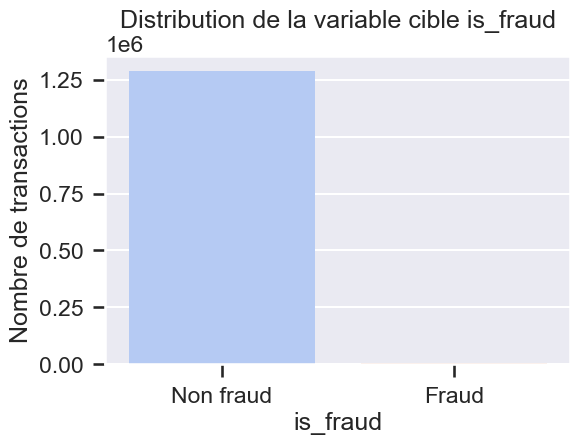

In [24]:
fraud_counts = df_train['is_fraud'].value_counts().sort_index()
fraud_pct = 100 * fraud_counts / fraud_counts.sum()
display(pd.concat([fraud_counts, fraud_pct], axis=1, keys=['count', 'pct']))

plt.figure(figsize=(6,4))
sns.barplot(x=fraud_counts.index, y=fraud_counts.values, palette='coolwarm')
plt.xticks([0,1], ['Non fraud', 'Fraud'])
plt.ylabel('Nombre de transactions')
plt.title('Distribution de la variable cible is_fraud')
plt.show()

Le dataset d'entraînement est fortement déséquilibré : la grande majorité des transactions sont légitimes.
Cela implique que les métriques de classification doivent être adaptées et que l’on doit analyser les patterns de fraude séparément.

## 6. Analyse de la variable `amt`

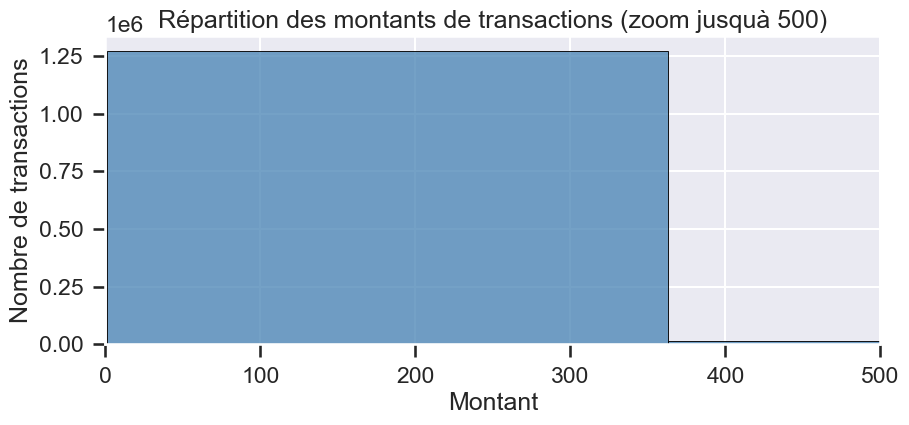

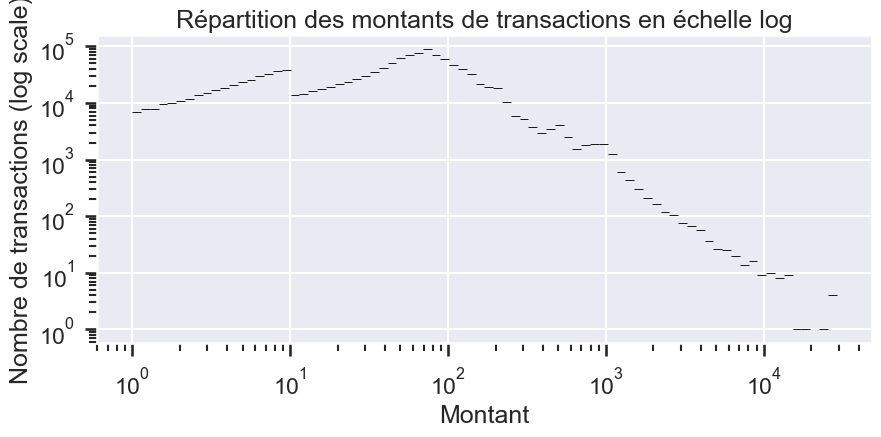

In [25]:
amt_stats = df_train['amt'].describe()
amt_stats

plt.figure(figsize=(10,4))
sns.histplot(df_train['amt'], bins=80, kde=False, color='steelblue')
plt.xlim(0, 500)
plt.title('Répartition des montants de transactions (zoom jusquà 500)')
plt.xlabel('Montant')
plt.ylabel('Nombre de transactions')
plt.show()

plt.figure(figsize=(10,4))
sns.histplot(df_train[df_train['amt'] > 0]['amt'], bins=80, log_scale=(True, True), color='darkorange')
plt.title('Répartition des montants de transactions en échelle log')
plt.xlabel('Montant')
plt.ylabel('Nombre de transactions (log scale)')
plt.show()

Le montant moyen est relativement bas mais la distribution est très asymétrique, avec une longue queue de transactions de très gros montant.
Cette observation est typique dun dataset de transactions financières.

## 7. Analyse temporelle

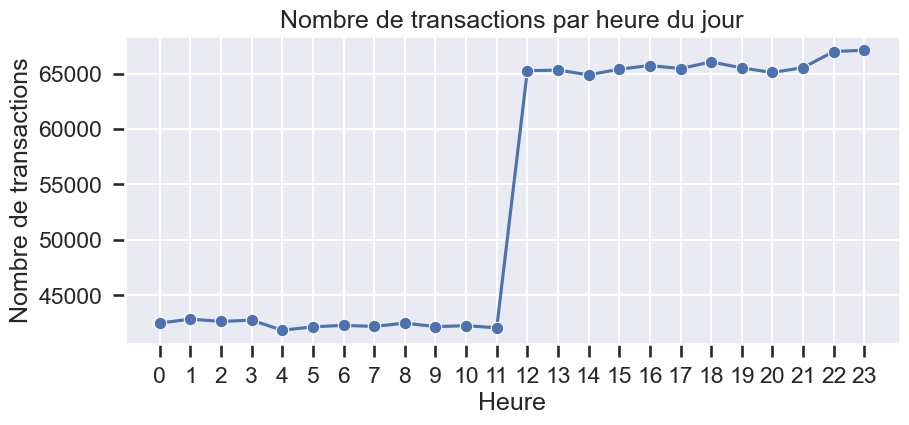

C:\Users\Imane\AppData\Local\Temp\ipykernel_22388\1230021626.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weekday_counts.index, y=weekday_counts.values, palette='viridis')


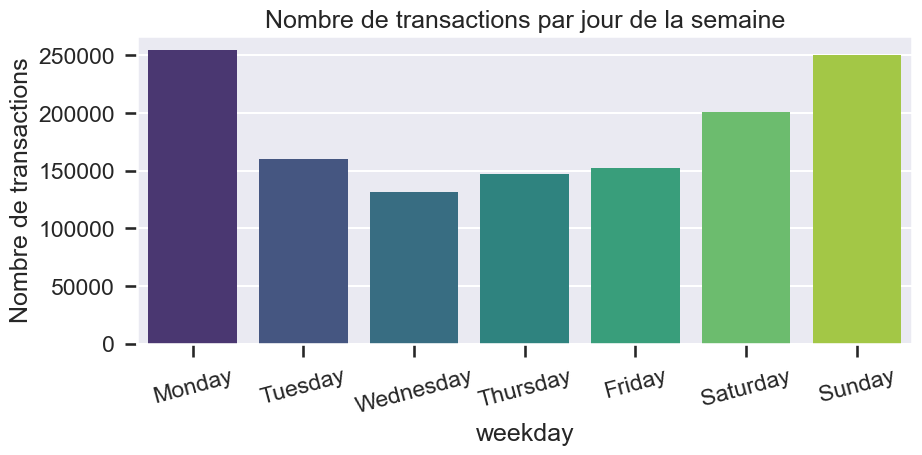

In [26]:
df_train['hour'] = df_train['trans_date_trans_time'].dt.hour
df_train['day'] = df_train['trans_date_trans_time'].dt.date
df_train['weekday'] = df_train['trans_date_trans_time'].dt.day_name()

hour_counts = df_train['hour'].value_counts().sort_index()
plt.figure(figsize=(10,4))
sns.lineplot(x=hour_counts.index, y=hour_counts.values, marker='o')
plt.title('Nombre de transactions par heure du jour')
plt.xlabel('Heure')
plt.ylabel('Nombre de transactions')
plt.xticks(range(0,24))
plt.show()

weekday_counts = df_train['weekday'].value_counts().reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.figure(figsize=(10,4))
sns.barplot(x=weekday_counts.index, y=weekday_counts.values, palette='viridis')
plt.xticks(rotation=15)
plt.title('Nombre de transactions par jour de la semaine')
plt.ylabel('Nombre de transactions')
plt.show()

Lactivité des transactions est répartie sur toute la journée, avec des pics pendant les heures actives.
Lanalyse journalière peut révéler des différences entre jours ouvrés et week-end.

## 8. Analyse des variables catégorielles

- category ---


category
gas_transport     131659
grocery_pos       123638
home              123115
shopping_pos      116672
kids_pets         113035
shopping_net       97543
entertainment      94014
food_dining        91461
personal_care      90758
health_fitness     85879
Name: count, dtype: int64

- gender ---


gender
F    709863
M    586812
Name: count, dtype: int64

- state ---


state
TX    94876
NY    83501
PA    79847
CA    56360
OH    46480
MI    46154
IL    43252
FL    42671
AL    40989
MO    38403
Name: count, dtype: int64

C:\Users\Imane\AppData\Local\Temp\ipykernel_22388\1831655350.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_cat.index, x=top_cat.values, palette='mako')


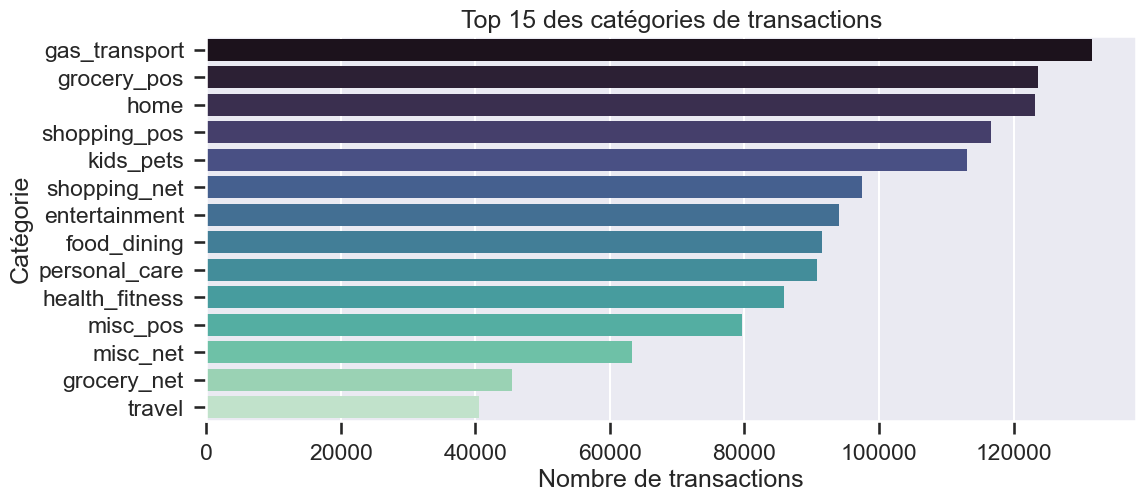

In [27]:
cat_vars = ['category', 'gender', 'state']
for col in cat_vars:
    print(f'- {col} ---')
    display(df_train[col].value_counts(dropna=False).head(10))

plt.figure(figsize=(12,5))
top_cat = df_train['category'].value_counts().head(15)
sns.barplot(y=top_cat.index, x=top_cat.values, palette='mako')
plt.title('Top 15 des catégories de transactions')
plt.xlabel('Nombre de transactions')
plt.ylabel('Catégorie')
plt.show()

Les catégories de transaction les plus fréquentes sont liées aux achats en ligne, à lalimentation et aux transports.
Il est utile de suivre celles-ci pour détecter des écarts chez les transactions frauduleuses.

## 9. Relation entre le montant et la fraude

C:\Users\Imane\AppData\Local\Temp\ipykernel_22388\3908573562.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_fraud', y='amt', data=df_train[df_train['amt'] <= 1000], palette='Set2')


<Figure size 1000x500 with 0 Axes>

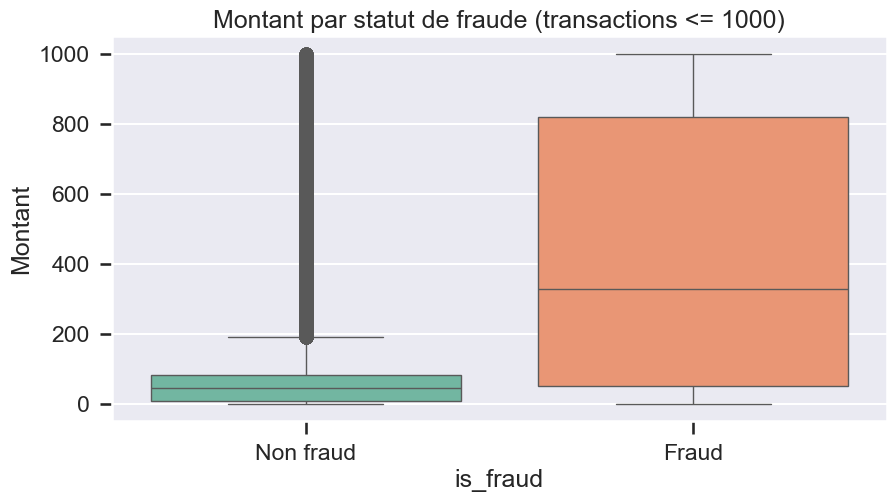

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,1289169.0,67.667110,154.007971,1.00,9.6100,47.280,82.540,28948.90
1,7506.0,531.320092,390.560070,1.06,245.6625,396.505,900.875,1376.04


In [30]:
plt.figure(figsize=(10,5))
sns.boxplot(x='is_fraud', y='amt', data=df_train[df_train['amt'] <= 1000], palette='Set2')
plt.title('Montant par statut de fraude (transactions <= 1000)')
plt.xlabel('is_fraud')
plt.ylabel('Montant')
plt.xticks([0,1], ['Non fraud', 'Fraud'])
plt.show()

fraud_amt = df_train.groupby('is_fraud')['amt'].describe()
fraud_amt

La comparaison des montants entre transactions légitimes et frauduleuses aide à identifier si les fraudes ont tendance à se produire sur des montants particuliers.
Cette analyse peut indiquer si un seuil de montant élevé mérite une inspection plus poussée.

## 10. Analyse des variables géographiques

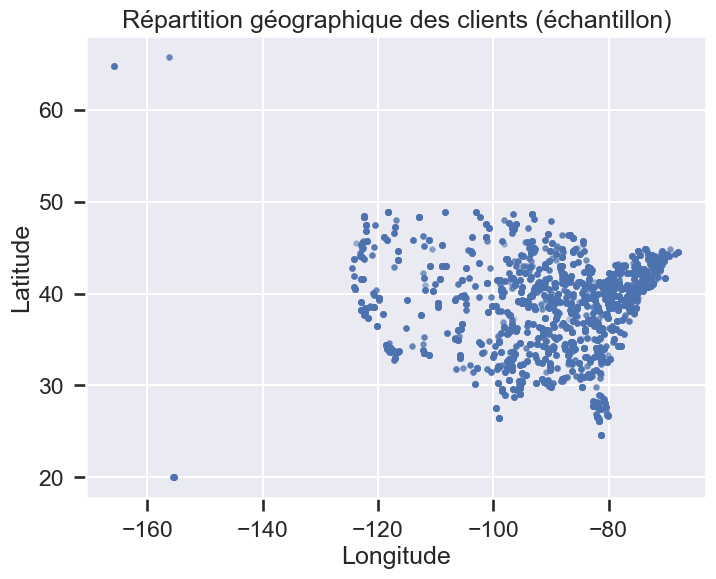

In [28]:
geo_vars = ['lat', 'long', 'merch_lat', 'merch_long']
df_train[geo_vars].describe()

plt.figure(figsize=(8,6))
plt.scatter(df_train['long'].sample(20000, random_state=42), df_train['lat'].sample(20000, random_state=42), alpha=0.15, s=10)
plt.title('Répartition géographique des clients (échantillon)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

Les coordonnées montrent la distribution géographique des utilisateurs. Une analyse plus fine peut explorer les distances entre la position du client et celle du marchand, ou les anomalies de localisation.

## 11. Analyse par noeud

In [31]:
node_paths = {
    'node_1': 'data/node_1/local_data.csv',
    'node_2': 'data/node_2/local_data.csv',
    'node_3': 'data/node_3/local_data.csv',
    'node_4': 'data/node_4/local_data.csv',
}

nodes = {}
for name, path in node_paths.items():
    nodes[name] = pd.read_csv(path, index_col=0, parse_dates=['trans_date_trans_time'], low_memory=False)
    nodes[name]['hour'] = nodes[name]['trans_date_trans_time'].dt.hour
    nodes[name]['weekday'] = nodes[name]['trans_date_trans_time'].dt.day_name()

for name, df in nodes.items():
    print(name, 'shape =', df.shape, '| fraud ratio =', round(df['is_fraud'].mean() * 100, 4), '%')

node_1 shape = (365148, 24) | fraud ratio = 0.5954 %
node_2 shape = (334661, 24) | fraud ratio = 0.6096 %
node_3 shape = (342837, 24) | fraud ratio = 0.5134 %
node_4 shape = (252448, 24) | fraud ratio = 0.5993 %


Nous chargeons les données de chaque noeud et ajoutons des colonnes temporelles utiles pour l'analyse locale. Nous comparons d'abord les dimensions et le taux de fraude pour chaque noeud.

In [32]:
def summarize_node(df):
    return {
        'transactions': len(df),
        'fraud_ratio_pct': round(100 * df['is_fraud'].mean(), 4),
        'unique_users': df['cc_num'].nunique(),
        'unique_merchants': df['merchant'].nunique(),
        'unique_categories': df['category'].nunique(),
        'unique_states': df['state'].nunique(),
        'top_category': df['category'].value_counts().index[0],
        'top_state': df['state'].value_counts().index[0],
        'female_ratio_pct': round(100 * (df['gender'] == 'F').mean(), 4),
        'male_ratio_pct': round(100 * (df['gender'] == 'M').mean(), 4),
        'amt_mean': round(df['amt'].mean(), 2),
        'amt_median': round(df['amt'].median(), 2),
        'amt_max': round(df['amt'].max(), 2),
    }

summary_df = pd.DataFrame([summarize_node(df) for df in nodes.values()], index=nodes.keys())
summary_df

,transactions,fraud_ratio_pct,unique_users,unique_merchants,unique_categories,unique_states,top_category,top_state,female_ratio_pct,male_ratio_pct,amt_mean,amt_median,amt_max
node_1,365148,0.5954,294,693,14,48,gas_transport,PA,54.4971,45.5029,69.66,47.31,27390.12
node_2,334661,0.6096,245,693,14,49,gas_transport,TX,55.2326,44.7674,70.54,47.84,28948.90
node_3,342837,0.5134,245,693,14,46,gas_transport,TX,52.4488,47.5512,70.64,46.82,26544.12
node_4,252448,0.5993,196,693,14,46,gas_transport,NY,57.9177,42.0823,70.70,48.32,25086.94


Ce résumé compare les caractéristiques essentielles de chaque noeud : volume, risque, diversité des utilisateurs, catégories et montants.

### 11.1 Noeud 1 : `data/node_1/local_data.csv`

Shape: (365148, 24)
Fraud ratio (%) : 0.5954
Unique users : 294
Top categories :
category
gas_transport     38174
grocery_pos       34920
home              34851
shopping_pos      32703
kids_pets         32361
shopping_net      27324
entertainment     26316
personal_care     25623
food_dining       25437
health_fitness    24269
Name: count, dtype: int64
Top states :
state
PA    28607
CA    26240
TX    21006
OH    16935
NY    15338
NC    13935
WI    13907
MN    13871
MO    13317
FL    12908
Name: count, dtype: int64
Gender distribution :
gender
F    198995
M    166153
Name: count, dtype: int64


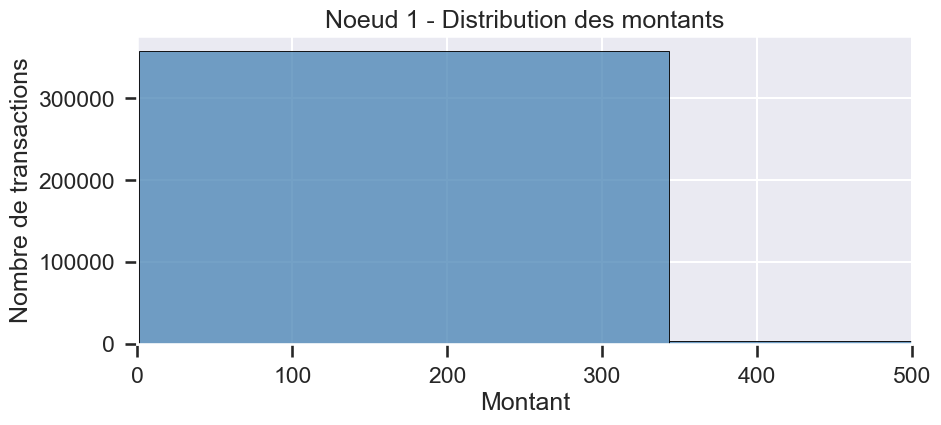

C:\Users\Imane\AppData\Local\Temp\ipykernel_22388\1132180820.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='hour', data=df, palette='viridis')


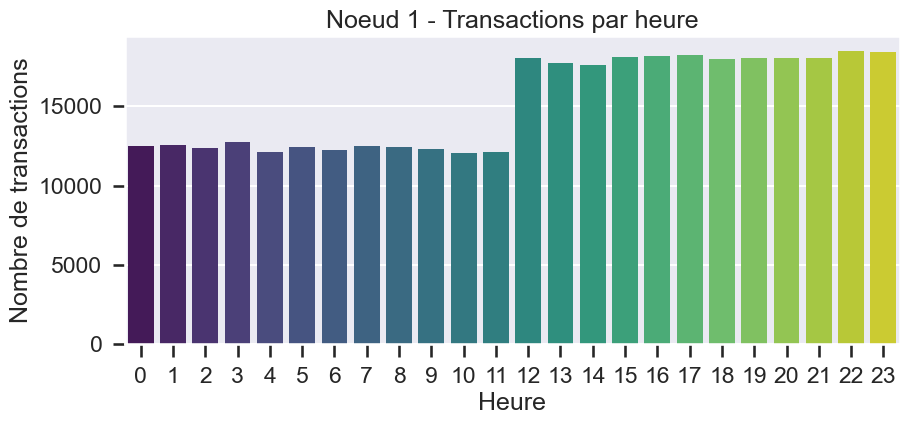

In [33]:
df = nodes['node_1']
print('Shape:', df.shape)
print('Fraud ratio (%) :', round(100 * df['is_fraud'].mean(), 4))
print('Unique users :', df['cc_num'].nunique())
print('Top categories :')
print(df['category'].value_counts().head(10))
print('Top states :')
print(df['state'].value_counts().head(10))
print('Gender distribution :')
print(df['gender'].value_counts(dropna=False))

plt.figure(figsize=(10,4))
sns.histplot(df['amt'], bins=80, color='steelblue')
plt.xlim(0, 500)
plt.title('Noeud 1 - Distribution des montants')
plt.xlabel('Montant')
plt.ylabel('Nombre de transactions')
plt.show()

plt.figure(figsize=(10,4))
sns.countplot(x='hour', data=df, palette='viridis')
plt.title('Noeud 1 - Transactions par heure')
plt.xlabel('Heure')
plt.ylabel('Nombre de transactions')
plt.show()

### 11.2 Noeud 2 : `data/node_2/local_data.csv`

Shape: (334661, 24)
Fraud ratio (%) : 0.6096
Unique users : 245
Top categories :
category
gas_transport     34615
grocery_pos       31749
home              31615
shopping_pos      29770
kids_pets         29015
shopping_net      25452
entertainment     24300
personal_care     23523
food_dining       23521
health_fitness    22231
Name: count, dtype: int64
Top states :
state
TX    29212
NY    28619
PA    19080
MI    14947
IL    14262
OK    13393
MO    12815
IN    11161
NE    10767
MN    10611
Name: count, dtype: int64
Gender distribution :
gender
F    184842
M    149819
Name: count, dtype: int64


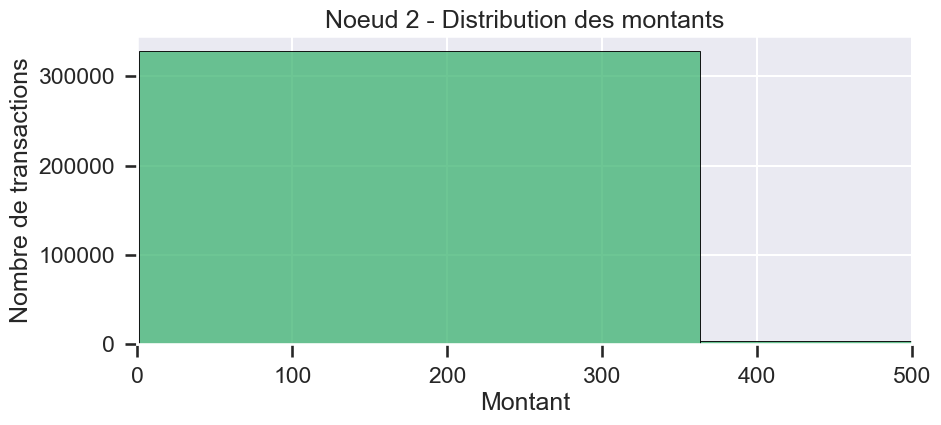

C:\Users\Imane\AppData\Local\Temp\ipykernel_22388\3693133616.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='weekday', data=df, order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'], palette='crest')


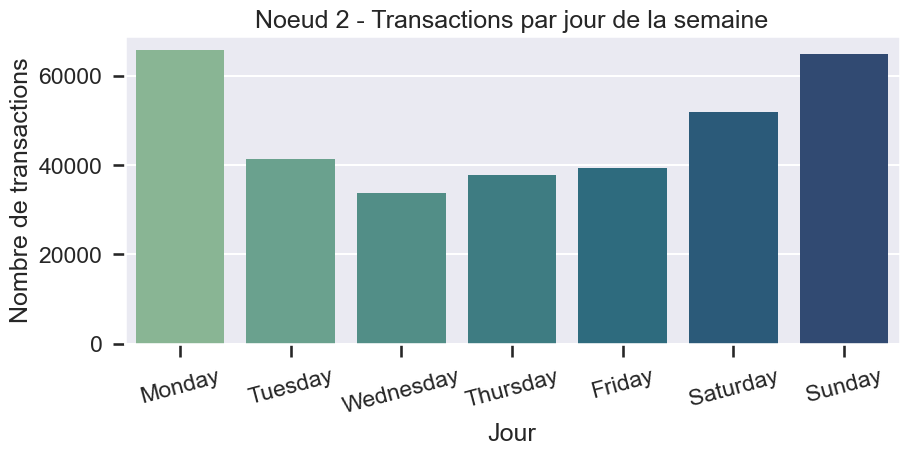

In [34]:
df = nodes['node_2']
print('Shape:', df.shape)
print('Fraud ratio (%) :', round(100 * df['is_fraud'].mean(), 4))
print('Unique users :', df['cc_num'].nunique())
print('Top categories :')
print(df['category'].value_counts().head(10))
print('Top states :')
print(df['state'].value_counts().head(10))
print('Gender distribution :')
print(df['gender'].value_counts(dropna=False))

plt.figure(figsize=(10,4))
sns.histplot(df['amt'], bins=80, color='mediumseagreen')
plt.xlim(0, 500)
plt.title('Noeud 2 - Distribution des montants')
plt.xlabel('Montant')
plt.ylabel('Nombre de transactions')
plt.show()

plt.figure(figsize=(10,4))
sns.countplot(x='weekday', data=df, order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'], palette='crest')
plt.title('Noeud 2 - Transactions par jour de la semaine')
plt.xlabel('Jour')
plt.ylabel('Nombre de transactions')
plt.xticks(rotation=15)
plt.show()

### 11.3 Noeud 3 : `data/node_3/local_data.csv`

Shape: (342837, 24)
Fraud ratio (%) : 0.5134
Unique users : 245
Top categories :
category
gas_transport     33678
grocery_pos       32392
home              32162
shopping_pos      30928
kids_pets         29625
shopping_net      26128
entertainment     24976
food_dining       24437
personal_care     23774
health_fitness    23057
Name: count, dtype: int64
Top states :
state
TX    31274
PA    21088
NY    21060
OH    17852
MI    15299
CA    14312
IA    13692
FL    11766
IL    11080
TN    10817
Name: count, dtype: int64
Gender distribution :
gender
F    179814
M    163023
Name: count, dtype: int64


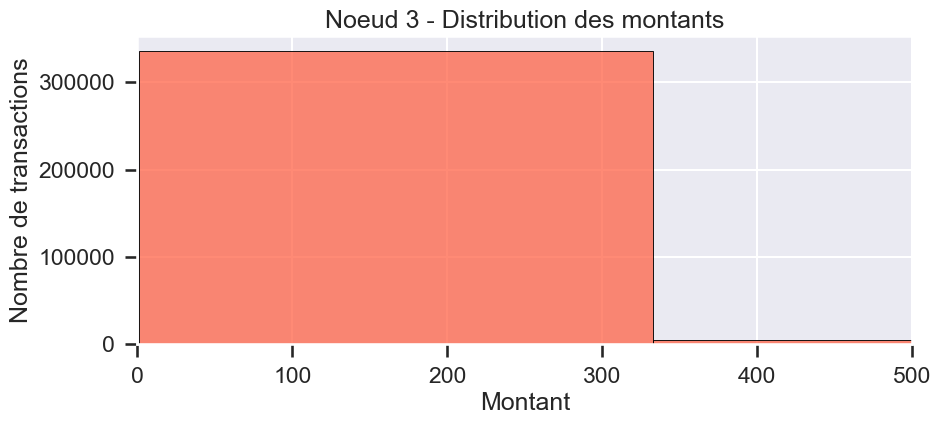

C:\Users\Imane\AppData\Local\Temp\ipykernel_22388\546484811.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cat.values, y=top_cat.index, palette='rocket')


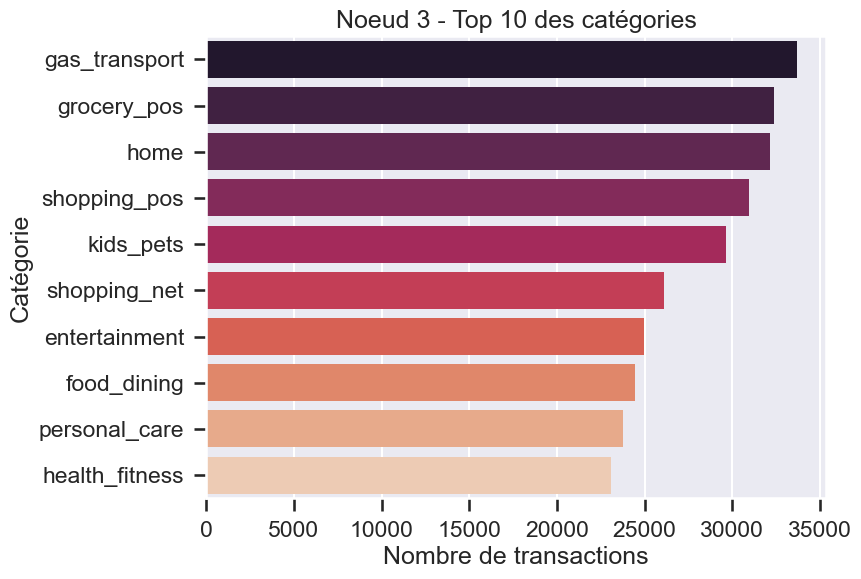

In [35]:
df = nodes['node_3']
print('Shape:', df.shape)
print('Fraud ratio (%) :', round(100 * df['is_fraud'].mean(), 4))
print('Unique users :', df['cc_num'].nunique())
print('Top categories :')
print(df['category'].value_counts().head(10))
print('Top states :')
print(df['state'].value_counts().head(10))
print('Gender distribution :')
print(df['gender'].value_counts(dropna=False))

plt.figure(figsize=(10,4))
sns.histplot(df['amt'], bins=80, color='tomato')
plt.xlim(0, 500)
plt.title('Noeud 3 - Distribution des montants')
plt.xlabel('Montant')
plt.ylabel('Nombre de transactions')
plt.show()

plt.figure(figsize=(8,6))
top_cat = df['category'].value_counts().head(10)
sns.barplot(x=top_cat.values, y=top_cat.index, palette='rocket')
plt.title('Noeud 3 - Top 10 des catégories')
plt.xlabel('Nombre de transactions')
plt.ylabel('Catégorie')
plt.show()

### 11.4 Noeud 4 : `data/node_4/local_data.csv`

Shape: (252448, 24)
Fraud ratio (%) : 0.5993
Unique users : 196
Top categories :
category
gas_transport     25042
grocery_pos       24407
home              24320
shopping_pos      23110
kids_pets         21887
shopping_net      18561
entertainment     18291
food_dining       17944
personal_care     17739
health_fitness    16232
Name: count, dtype: int64
Top states :
state
NY    18484
AL    14305
TX    13384
FL    12842
PA    11072
CA    10714
MD     9726
OK     9680
AR     9230
KY     8074
Name: count, dtype: int64
Gender distribution :
gender
F    146212
M    106236
Name: count, dtype: int64


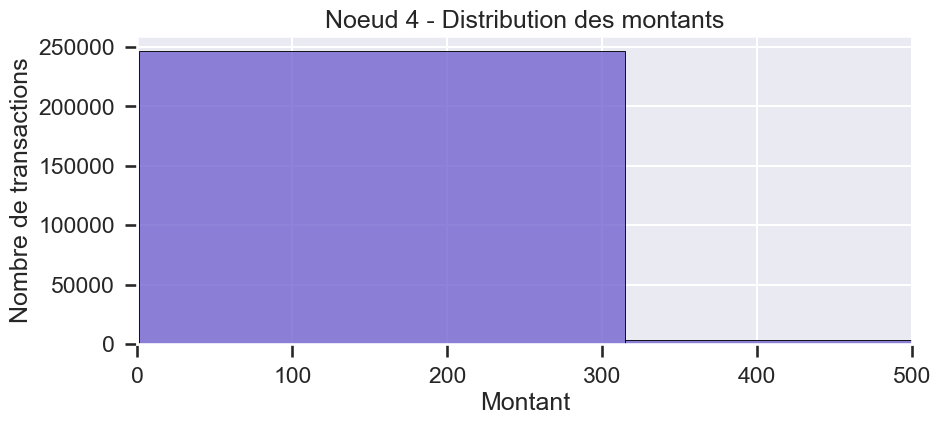

C:\Users\Imane\AppData\Local\Temp\ipykernel_22388\4157352403.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='gender', data=df, palette='pastel')


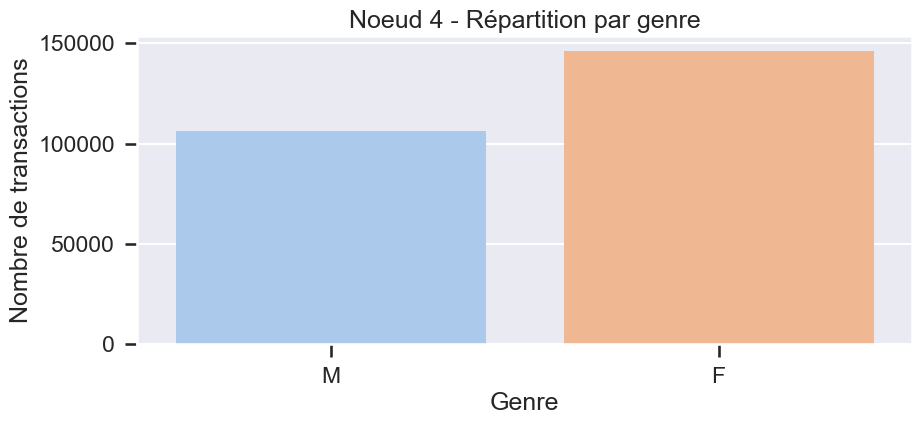

In [36]:
df = nodes['node_4']
print('Shape:', df.shape)
print('Fraud ratio (%) :', round(100 * df['is_fraud'].mean(), 4))
print('Unique users :', df['cc_num'].nunique())
print('Top categories :')
print(df['category'].value_counts().head(10))
print('Top states :')
print(df['state'].value_counts().head(10))
print('Gender distribution :')
print(df['gender'].value_counts(dropna=False))

plt.figure(figsize=(10,4))
sns.histplot(df['amt'], bins=80, color='slateblue')
plt.xlim(0, 500)
plt.title('Noeud 4 - Distribution des montants')
plt.xlabel('Montant')
plt.ylabel('Nombre de transactions')
plt.show()

plt.figure(figsize=(10,4))
sns.countplot(x='gender', data=df, palette='pastel')
plt.title('Noeud 4 - Répartition par genre')
plt.xlabel('Genre')
plt.ylabel('Nombre de transactions')
plt.show()

## 12. Comparaison des noeuds

<Figure size 1000x500 with 0 Axes>

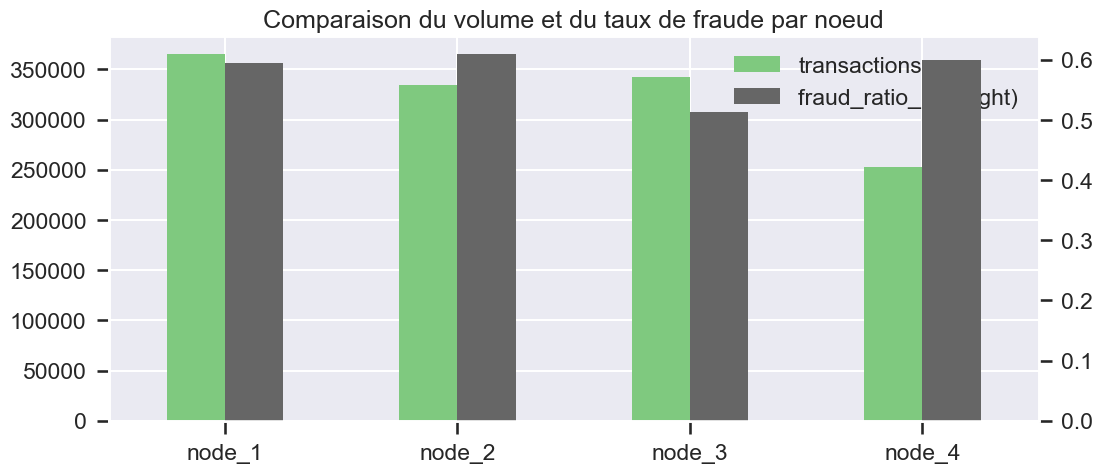

C:\Users\Imane\AppData\Local\Temp\ipykernel_22388\2518969866.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=compare.index, y=compare['amt_mean'], palette='magma')


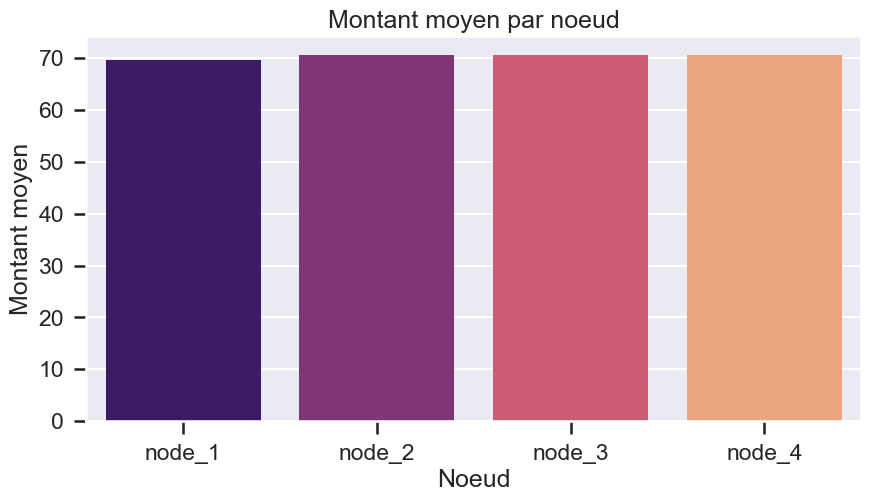

In [37]:
compare = summary_df.copy()

plt.figure(figsize=(10,5))
compare[['transactions', 'fraud_ratio_pct']].plot(kind='bar', secondary_y='fraud_ratio_pct', rot=0, figsize=(12,5), colormap='Accent')
plt.title('Comparaison du volume et du taux de fraude par noeud')
plt.xlabel('Noeud')
plt.show()

plt.figure(figsize=(10,5))
sns.barplot(x=compare.index, y=compare['amt_mean'], palette='magma')
plt.title('Montant moyen par noeud')
plt.xlabel('Noeud')
plt.ylabel('Montant moyen')
plt.show()

Cette comparaison aide à repérer les noeuds avec un taux de fraude plus élevé, un volume différent ou une distribution de montants distincte.\n
Les différences entre noeuds peuvent révéler des biais de segmentation ou des profils de comportement différents selon les groupes d'utilisateurs alloués.

## 13. Interprétation et synthèse globale

### Points clés
- Le dataset principal (`fraudTrain.csv`) est fortement déséquilibré vers les transactions non frauduleuses, ce qui exige d'utiliser des métriques robustes et des méthodes de validation adaptées.
- La distribution du montant `amt` est très asymétrique, avec une longue queue de gros montants ; ces transactions représentent un signal important pour la détection de fraude.
- Les variables temporelles montrent des cycles journaliers attendus, mais les fraudes peuvent se manifester à des heures ou des jours différents des transactions légitimes.
- Les catégories de transaction dominantes sont liées aux achats, à l'alimentation et aux transports. Une attention particulière doit être portée aux catégories surreprésentées dans les cas frauduleux.
- La géolocalisation client vs marchand est une source de features prometteuse : les anomalies de distance ou de lieu peuvent aider à détecter des transactions inhabituelles.

### Synthèse par noeud
- **Node 1** : utile pour étudier la distribution des montants et l'activité par heure. Ce noeud peut révéler des patterns de comportement spécifiques à un segment particulier.
- **Node 2** : il présente un volume élevé et un profil temporel distinct. L'analyse du jour de la semaine permet de vérifier si le comportement des transactions est différent des autres noeuds.
- **Node 3** : la répartition des catégories de transaction est intéressante ici, ce qui peut indiquer un segment d'utilisateurs ou de commerçants spécifique.
- **Node 4** : la comparaison par genre et par état est plus marquée, ce qui suggère une segmentation possible basée sur le profil utilisateur.


### Points clés
- Le dataset principal (`fraudTrain.csv`) est fortement déséquilibré vers les transactions non frauduleuses, ce qui exige d'utiliser des métriques robustes et des méthodes de validation adaptées.
- La distribution du montant `amt` est très asymétrique, avec une longue queue de gros montants ; ces transactions représentent un signal important pour la détection de fraude.
- Les variables temporelles montrent des cycles journaliers attendus, mais les fraudes peuvent se manifester à des heures ou des jours différents des transactions légitimes.
- Les catégories de transaction dominantes sont liées aux achats, à l'alimentation et aux transports. Une attention particulière doit être portée aux catégories surreprésentées dans les cas frauduleux.
- La géolocalisation client vs marchand est une source de features prometteuse : les anomalies de distance ou de lieu peuvent aider à détecter des transactions inhabituelles.